# Betting Against Beta (BAB) — Frazzini & Pedersen (2014)

**Paper**: *Betting Against Beta* — Andrea Frazzini & Lasse Heje Pedersen, Journal of Financial Economics 111 (2014) 1–25

## Core Idea
The CAPM predicts that higher-beta assets should earn higher returns. In practice, the security market line is **too flat** — low-beta stocks earn too much alpha and high-beta stocks too little. The cause: leverage-constrained investors (mutual funds, pension funds, retail) cannot apply leverage, so they *tilt toward high-beta* assets instead, bidding up their price and driving down their risk-adjusted return.

The **BAB factor** exploits this by:
- Going **long a leverage portfolio of low-beta stocks** (scaled to β = 1)
- Going **short a de-leveraged portfolio of high-beta stocks** (scaled to β = 1)
- The resulting portfolio is **market-neutral** (zero net beta)

## Implementation (adapted for Indian Equities — NIFTY 50 universe)

### Beta Estimation (Eq. 14–15 of the paper)
$$\hat{\beta}_i = \hat{\rho}_i \cdot \frac{\hat{\sigma}_i}{\hat{\sigma}_m}$$

- $\hat{\sigma}_i$, $\hat{\sigma}_m$: 1-year (252-day) rolling volatility
- $\hat{\rho}_i$: 5-year (1260-day) rolling correlation with market
- **Vasicek shrinkage**: $\hat{\beta}^{shrunk}_i = 0.6 \cdot \hat{\beta}_i + 0.4 \cdot 1$

### Portfolio Construction (Eq. 16–17 of the paper)
Monthly rebalancing. Rank stocks by beta; split at median:
$$w_H = k(z - \bar{z})^+, \quad w_L = k(\bar{z} - z)^+$$
where $k = 2/\mathbf{1}'|z - \bar{z}|$ normalises each portfolio to sum to 1.

### BAB Factor Return (Eq. 17)
$$r^{BAB}_{t+1} = \frac{1}{\beta^L_t}\left(r^L_{t+1} - r^f\right) - \frac{1}{\beta^H_t}\left(r^H_{t+1} - r^f\right)$$

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import norm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATA_DIR = '../dataset'
MARKET_FILE = 'NIFTY.csv'

# ── Risk-free rate proxy (India 91-day T-bill ≈ 6% p.a.) ──────────────────
RF_ANNUAL = 0.06
RF_DAILY  = (1 + RF_ANNUAL) ** (1/252) - 1

# ── Beta-estimation windows (paper §3.1) ──────────────────────────────────
VOL_WINDOW  = 252     # 1-year rolling volatility
CORR_WINDOW = 1260    # 5-year rolling correlation
SHRINK_W    = 0.6     # Vasicek shrinkage weight toward TS estimate
SHRINK_XS   = 1.0     # Cross-sectional mean beta (set to 1)

# ── Transaction cost assumption ────────────────────────────────────────────
TRANSACTION_COST = 0.0010  # 10 bps one-way

print(f'Daily risk-free rate: {RF_DAILY*100:.4f}%  |  Annual: {RF_ANNUAL*100:.1f}%')

Daily risk-free rate: 0.0231%  |  Annual: 6.0%


## 1 · Load Data

In [2]:
def load_price_series(filepath, col='close'):
    df = pd.read_csv(filepath, parse_dates=['date'])
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None).dt.normalize()
    df = df.sort_values('date').drop_duplicates('date')
    return df.set_index('date')[col].rename(os.path.basename(filepath).replace('.csv',''))

# Market index
market_price = load_price_series(os.path.join(DATA_DIR, MARKET_FILE))
market_ret   = np.log(market_price / market_price.shift(1)).dropna()

# Individual stocks (exclude index files)
EXCLUDE = {'NIFTY', 'NIFTY_MIDCAP_100', 'SENSEX', 'BANKNIFTY'}
stock_files = sorted([
    f for f in os.listdir(DATA_DIR)
    if f.endswith('.csv') and f.replace('.csv','') not in EXCLUDE
])

price_df = pd.DataFrame({
    f.replace('.csv',''): load_price_series(os.path.join(DATA_DIR, f))
    for f in stock_files
})

# Log returns
ret_df = np.log(price_df / price_df.shift(1))

# Align to market
common_idx = market_ret.index.intersection(ret_df.index)
market_ret  = market_ret.loc[common_idx]
ret_df      = ret_df.loc[common_idx]

# Trim leading NaNs
first_valid = ret_df.notna().any(axis=1).idxmax()
ret_df      = ret_df.loc[first_valid:]
market_ret  = market_ret.loc[first_valid:]

print(f'Universe  : {ret_df.shape[1]} stocks')
print(f'Date range: {ret_df.index[0].date()} → {ret_df.index[-1].date()}')
print(f'Market    : {market_ret.shape[0]} daily observations')

Universe  : 49 stocks
Date range: 2000-01-03 → 2026-04-29
Market    : 6545 daily observations


## 2 · Estimate Betas

Following Eq. 14 in the paper:
- **Volatility** estimated on a 1-year (252-day) rolling window  
- **Correlation** estimated on a 5-year (1260-day) rolling window  
- **Vasicek shrinkage** toward cross-sectional mean of 1

In [3]:
# ── Rolling volatilities ───────────────────────────────────────────────────
stock_vol  = ret_df.rolling(VOL_WINDOW, min_periods=126).std() * np.sqrt(252)
market_vol = market_ret.rolling(VOL_WINDOW, min_periods=126).std() * np.sqrt(252)

# ── Rolling correlations ──────────────────────────────────────────────────
def rolling_corr_with_market(stock_rets, mkt_rets, window, min_periods):
    """Compute rolling correlation of each stock with the market."""
    result = pd.DataFrame(index=stock_rets.index, columns=stock_rets.columns, dtype=float)
    for col in stock_rets.columns:
        aligned = pd.concat([stock_rets[col], mkt_rets], axis=1).dropna()
        if len(aligned) < min_periods:
            continue
        corr = aligned.iloc[:,0].rolling(window, min_periods=min_periods).corr(aligned.iloc[:,1])
        result.loc[corr.index, col] = corr.values
    return result

print('Computing rolling correlations (5-year window) — this may take a moment…')
rolling_corr = rolling_corr_with_market(
    ret_df, market_ret,
    window=CORR_WINDOW, min_periods=CORR_WINDOW//2
)

# ── Raw time-series beta: σ_i/σ_m × ρ_im ─────────────────────────────────
beta_ts = rolling_corr.multiply(
    stock_vol.divide(market_vol, axis=0), axis=0
)

# ── Vasicek shrinkage toward cross-sectional mean of 1 (Eq. 15) ──────────
beta_shrunk = SHRINK_W * beta_ts + (1 - SHRINK_W) * SHRINK_XS
beta_shrunk = beta_shrunk.clip(lower=0.01)   # ensure positive betas

# ── Monthly snapshot: last beta of each month ─────────────────────────────
beta_monthly = beta_shrunk.resample('ME').last()

print(f'Beta estimation complete.')
print(f'Beta range (all stocks, all months): '
      f'{beta_monthly.stack().quantile(0.01):.3f} – {beta_monthly.stack().quantile(0.99):.3f}')

Computing rolling correlations (5-year window) — this may take a moment…
Beta estimation complete.
Beta range (all stocks, all months): 0.560 – 1.555


## 3 · Beta Distribution — Exploratory View

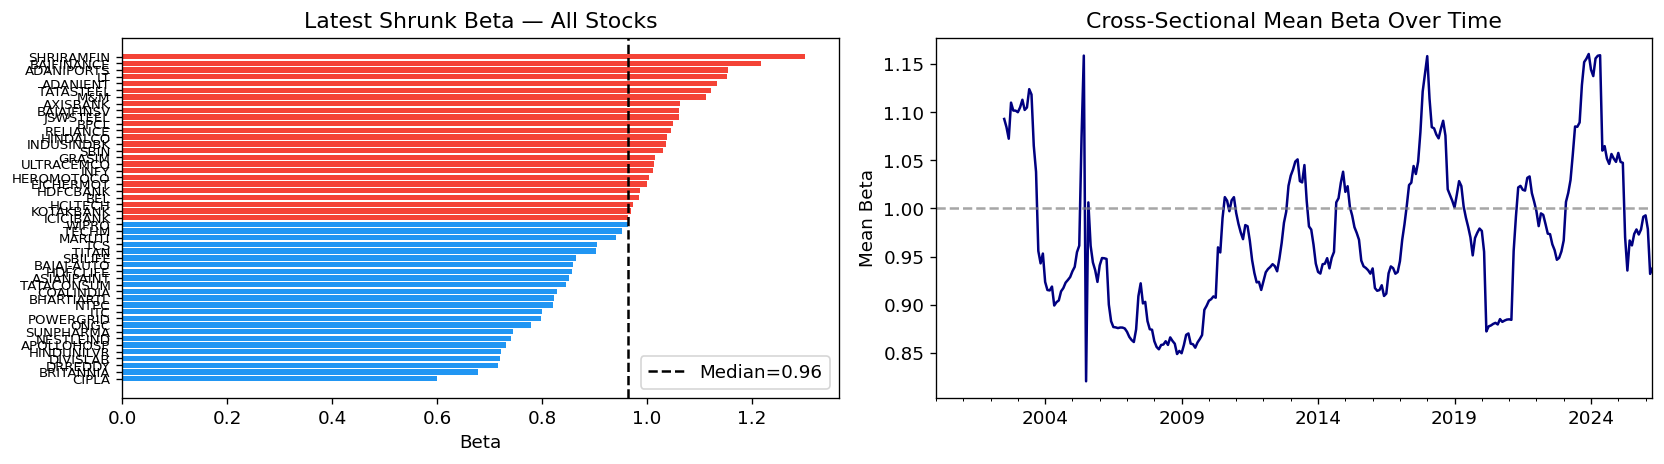

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of most-recent betas
latest_betas = beta_monthly.iloc[-1].dropna().sort_values()
axes[0].barh(range(len(latest_betas)), latest_betas.values, color=[
    '#2196F3' if b < latest_betas.median() else '#F44336' for b in latest_betas.values
])
axes[0].set_yticks(range(len(latest_betas)))
axes[0].set_yticklabels(latest_betas.index, fontsize=8)
axes[0].axvline(latest_betas.median(), color='k', linestyle='--', label=f'Median={latest_betas.median():.2f}')
axes[0].set_title('Latest Shrunk Beta — All Stocks')
axes[0].set_xlabel('Beta')
axes[0].legend()

# Cross-sectional mean beta over time
beta_monthly.mean(axis=1).plot(ax=axes[1], color='navy')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Cross-Sectional Mean Beta Over Time')
axes[1].set_ylabel('Mean Beta')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 4 · Monthly Portfolio Construction

**Steps** (applied at the end of each month, portfolio held next month):
1. Rank stocks by shrunk beta
2. Split at median → low-beta, high-beta groups
3. Rank-weight within each group
4. Rescale each portfolio to have ex-ante portfolio beta = 1

In [5]:
# Monthly stock returns (simple return from daily log returns)
monthly_log_ret = ret_df.resample('ME').sum()    # sum of log returns = log of compounded return
monthly_ret     = np.exp(monthly_log_ret) - 1    # convert to simple returns
market_monthly  = np.exp(market_ret.resample('ME').sum()) - 1
RF_MONTHLY      = (1 + RF_ANNUAL) ** (1/12) - 1  # monthly risk-free rate

def build_rank_weights(betas_row):
    """Given a Series of betas, return low-beta and high-beta rank weights.
    
    Following Eq. 16 of Frazzini & Pedersen (2014):
      z    = rank(beta)   [1 = lowest beta]
      z_bar = mean rank
      w_H  = k * max(z - z_bar, 0)    high-beta portfolio
      w_L  = k * max(z_bar - z, 0)    low-beta portfolio
      k    = 2 / sum(|z - z_bar|)
    """
    valid = betas_row.dropna()
    if len(valid) < 4:
        return pd.Series(dtype=float), pd.Series(dtype=float), np.nan, np.nan

    z    = valid.rank()               # ascending: rank 1 = lowest beta
    z_bar = z.mean()
    dev  = z - z_bar
    k    = 2.0 / dev.abs().sum()

    w_H = (dev.clip(lower=0) * k)    # positive deviations → high-beta portfolio
    w_L = ((-dev).clip(lower=0) * k) # negative deviations flipped → low-beta portfolio

    # Portfolio-level betas (dot product)
    beta_H = (w_H * valid).sum()
    beta_L = (w_L * valid).sum()

    return w_L, w_H, beta_L, beta_H


# ── Iterate month by month ────────────────────────────────────────────────
bab_returns   = []
long_returns  = []
short_returns = []
port_details  = []   # for turnover & capacity calculations

# Portfolio dates: beta estimated at end of month t, return realized in month t+1
formation_months = beta_monthly.index

prev_w_L = None
prev_w_H = None

for i, formation_date in enumerate(formation_months[:-1]):
    return_date = formation_months[i + 1]

    # Betas at formation
    betas = beta_monthly.loc[formation_date]

    # Stocks with valid returns in the holding month
    if return_date not in monthly_ret.index:
        continue
    rets_next = monthly_ret.loc[return_date]
    available = betas.dropna().index.intersection(rets_next.dropna().index)
    if len(available) < 4:
        continue

    betas_avail = betas[available]
    w_L, w_H, beta_L, beta_H = build_rank_weights(betas_avail)

    if beta_L <= 0 or beta_H <= 0:
        continue

    # Realised portfolio returns (simple)
    r_L = (w_L * rets_next[w_L.index]).sum()
    r_H = (w_H * rets_next[w_H.index]).sum()

    # BAB return (Eq. 17): scale each leg to beta=1, then long-minus-short
    excess_L = r_L - RF_MONTHLY
    excess_H = r_H - RF_MONTHLY
    r_bab = (1 / beta_L) * excess_L - (1 / beta_H) * excess_H

    # Turnover: fraction of portfolio weights that changed
    if prev_w_L is not None:
        combined_idx = w_L.index.union(prev_w_L.index)
        turn_L = (w_L.reindex(combined_idx, fill_value=0) - prev_w_L.reindex(combined_idx, fill_value=0)).abs().sum() / 2
        combined_idx_H = w_H.index.union(prev_w_H.index)
        turn_H = (w_H.reindex(combined_idx_H, fill_value=0) - prev_w_H.reindex(combined_idx_H, fill_value=0)).abs().sum() / 2
        turnover = (turn_L + turn_H) / 2
    else:
        turnover = 1.0

    prev_w_L = w_L.copy()
    prev_w_H = w_H.copy()

    bab_returns.append({'date': return_date, 'bab': r_bab, 'r_L': r_L, 'r_H': r_H,
                        'beta_L': beta_L, 'beta_H': beta_H,
                        'n_stocks': len(available), 'turnover': turnover})

bab_df = pd.DataFrame(bab_returns).set_index('date')
print(f'BAB backtest: {bab_df.index[0].date()} → {bab_df.index[-1].date()}')
print(f'Months       : {len(bab_df)}')
print(f'Avg stocks   : {bab_df.n_stocks.mean():.0f}')
print(f'Avg beta_L   : {bab_df.beta_L.mean():.3f}   Avg beta_H: {bab_df.beta_H.mean():.3f}')

BAB backtest: 2005-09-30 → 2026-04-30
Months       : 248
Avg stocks   : 45
Avg beta_L   : 0.757   Avg beta_H: 1.205


## 5 · Beta-Sorted Decile Portfolios

Replicating Table 3 of the paper — declining Sharpe ratios and alphas across beta deciles confirm the core prediction of the model.

      Quintile  Avg Beta  Avg Excess Ret  Ann. Vol (%)  Sharpe Ratio
 Q1 (Low Beta)      0.71           1.421         17.88         0.954
    Q2 ( Beta)      0.86           1.109         19.23         0.692
 Q3 (Mid Beta)      0.95           1.145         21.98         0.625
    Q4 ( Beta)      1.06           1.117         25.28         0.530
Q5 (High Beta)      1.27           1.265         35.12         0.432


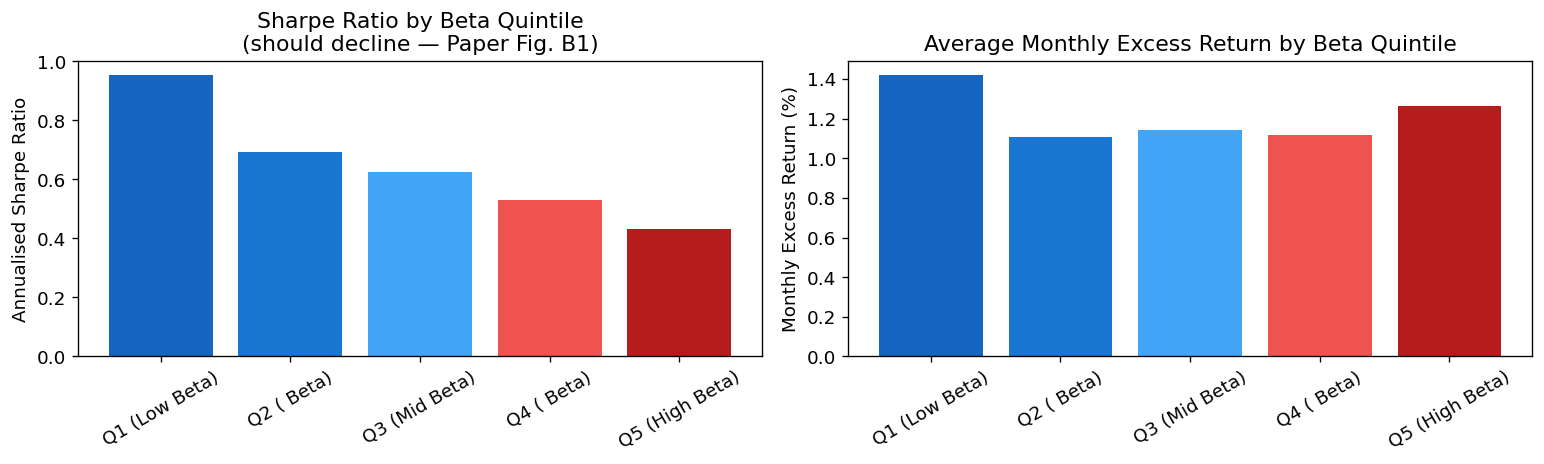

In [6]:
N_DECILES = 5   # use quintiles given our smaller universe

decile_monthly = {d: [] for d in range(1, N_DECILES+1)}

for i, formation_date in enumerate(formation_months[:-1]):
    return_date = formation_months[i + 1]
    if return_date not in monthly_ret.index:
        continue
    betas = beta_monthly.loc[formation_date]
    rets_next = monthly_ret.loc[return_date]
    available = betas.dropna().index.intersection(rets_next.dropna().index)
    if len(available) < N_DECILES * 2:
        continue

    betas_avail = betas[available]
    labels = pd.qcut(betas_avail, q=N_DECILES, labels=False) + 1  # 1=low, N=high

    for d in range(1, N_DECILES+1):
        members = labels[labels == d].index
        if len(members) == 0:
            continue
        r_port   = rets_next[members].mean()            # equal-weighted
        beta_avg = betas_avail[members].mean()
        decile_monthly[d].append({
            'date': return_date,
            'ret': r_port,
            'beta_avg': beta_avg
        })

# Summarise each decile
summary_rows = []
for d in range(1, N_DECILES+1):
    df_d = pd.DataFrame(decile_monthly[d]).set_index('date')
    if len(df_d) < 12:
        continue
    excess = df_d['ret'] - RF_MONTHLY
    sr = excess.mean() / excess.std() * np.sqrt(12)
    summary_rows.append({
        'Quintile': f'Q{d} ({["Low","","Mid","","High"][d-1]} Beta)',
        'Avg Beta':       round(df_d['beta_avg'].mean(), 2),
        'Avg Excess Ret': round(excess.mean() * 100, 3),
        'Ann. Vol (%)':   round(excess.std() * np.sqrt(12) * 100, 2),
        'Sharpe Ratio':   round(sr, 3),
    })

decile_summary = pd.DataFrame(summary_rows)
print(decile_summary.to_string(index=False))

# Plot declining Sharpe pattern
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(decile_summary['Quintile'], decile_summary['Sharpe Ratio'],
            color=['#1565C0','#1976D2','#42A5F5','#EF5350','#B71C1C'])
axes[0].set_title('Sharpe Ratio by Beta Quintile\n(should decline — Paper Fig. B1)')
axes[0].set_ylabel('Annualised Sharpe Ratio')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(decile_summary['Quintile'], decile_summary['Avg Excess Ret'],
            color=['#1565C0','#1976D2','#42A5F5','#EF5350','#B71C1C'])
axes[1].set_title('Average Monthly Excess Return by Beta Quintile')
axes[1].set_ylabel('Monthly Excess Return (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6 · BAB Factor Performance

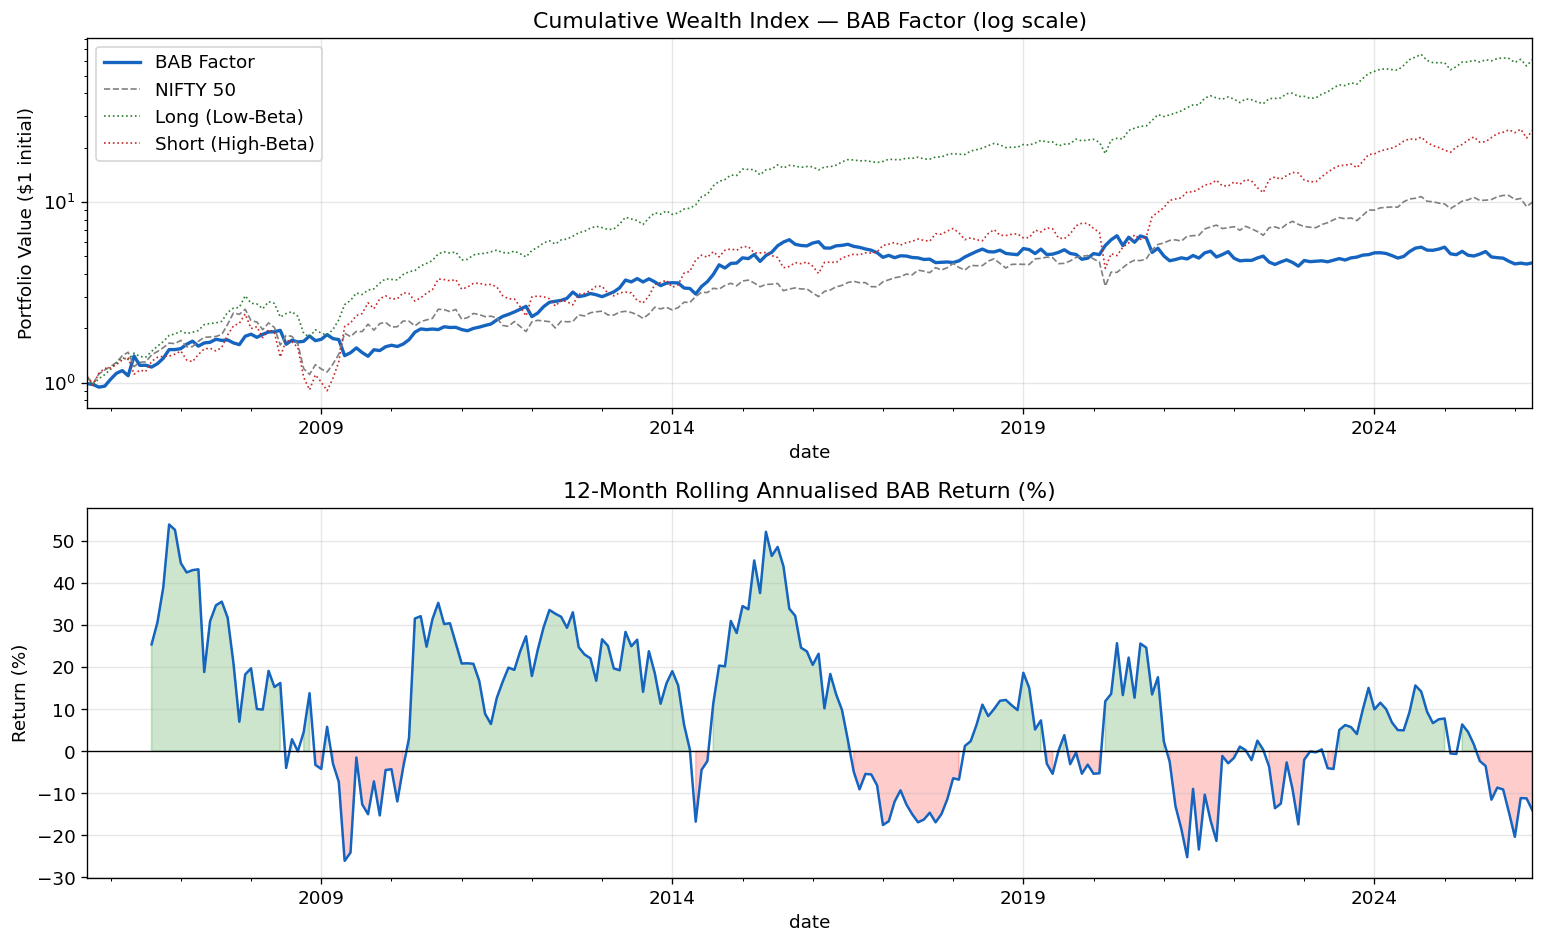

In [7]:
bab_ret   = bab_df['bab']
long_ret  = bab_df['r_L']
short_ret = bab_df['r_H']

# Cumulative wealth index (starts at $1)
cum_bab   = (1 + bab_ret).cumprod()
cum_long  = (1 + long_ret).cumprod()
cum_short = (1 + short_ret).cumprod()
cum_mkt   = (1 + market_monthly.loc[bab_ret.index]).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

cum_bab.plot(ax=axes[0],   color='#1565C0', linewidth=2, label='BAB Factor')
cum_mkt.plot(ax=axes[0],   color='gray',    linewidth=1, linestyle='--', label='NIFTY 50')
cum_long.plot(ax=axes[0],  color='#2E7D32', linewidth=1, linestyle=':', label='Long (Low-Beta)')
cum_short.plot(ax=axes[0], color='#C62828', linewidth=1, linestyle=':', label='Short (High-Beta)')
axes[0].set_yscale('log')
axes[0].set_title('Cumulative Wealth Index — BAB Factor (log scale)')
axes[0].set_ylabel('Portfolio Value ($1 initial)')
axes[0].legend()
axes[0].grid(alpha=0.3)

bab_ret.rolling(12).mean().mul(12).mul(100).plot(ax=axes[1], color='#1565C0')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].fill_between(bab_ret.index,
                     bab_ret.rolling(12).mean().mul(12).mul(100),
                     0, where=bab_ret.rolling(12).mean() > 0,
                     alpha=0.2, color='green')
axes[1].fill_between(bab_ret.index,
                     bab_ret.rolling(12).mean().mul(12).mul(100),
                     0, where=bab_ret.rolling(12).mean() <= 0,
                     alpha=0.2, color='red')
axes[1].set_title('12-Month Rolling Annualised BAB Return (%)')
axes[1].set_ylabel('Return (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7 · Performance Metrics

All metrics computed on the BAB factor monthly return series.

In [8]:
# ─────────────────────────────────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────

def max_drawdown(returns):
    """Maximum peak-to-trough decline in cumulative wealth."""
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min(), dd


def cagr(returns, periods_per_year=12):
    """Compound Annual Growth Rate."""
    total = (1 + returns).prod()
    n_years = len(returns) / periods_per_year
    return total ** (1 / n_years) - 1


def sharpe(returns, rf_per_period=0.0, periods_per_year=12):
    excess = returns - rf_per_period
    if excess.std() == 0:
        return np.nan
    return excess.mean() / excess.std() * np.sqrt(periods_per_year)


def sortino(returns, rf_per_period=0.0, periods_per_year=12):
    excess = returns - rf_per_period
    downside = excess[excess < 0]
    if len(downside) == 0 or downside.std() == 0:
        return np.nan
    downside_dev = np.sqrt((downside**2).mean()) * np.sqrt(periods_per_year)
    return excess.mean() * periods_per_year / downside_dev


def probabilistic_sharpe_ratio(returns, rf_per_period=0.0,
                                periods_per_year=12, sr_benchmark=0.0):
    """Bailey & Lopez de Prado (2012) PSR — probability that true SR > benchmark.

    PSR(SR*) = Φ[(SR_hat − SR*) × √(T−1) / √(1 − γ3·SR_hat + (γ4−1)/4·SR_hat²)]
    """
    excess = returns - rf_per_period
    T   = len(excess)
    sr_hat = excess.mean() / excess.std() * np.sqrt(periods_per_year)  # annualised SR
    sr_hat_monthly = excess.mean() / excess.std()                       # per-period SR
    gamma3 = stats.skew(excess)
    gamma4 = stats.kurtosis(excess, fisher=False)  # raw kurtosis

    variance_sr = (1 - gamma3 * sr_hat_monthly
                   + (gamma4 - 1) / 4 * sr_hat_monthly**2)
    if variance_sr <= 0:
        return np.nan

    z = (sr_hat - sr_benchmark) * np.sqrt(T - 1) / np.sqrt(variance_sr * periods_per_year)
    return norm.cdf(z)


def information_ratio(strat_returns, bench_returns, periods_per_year=12):
    active = strat_returns - bench_returns
    if active.std() == 0:
        return np.nan
    return active.mean() / active.std() * np.sqrt(periods_per_year)


# ─────────────────────────────────────────────────────────────────────────
# COMPUTE ALL METRICS
# ─────────────────────────────────────────────────────────────────────────

ret_series = bab_ret.dropna()
mkt_aligned = market_monthly.reindex(ret_series.index).fillna(0)

# 1. Runtime
start_date  = ret_series.index[0]
end_date    = ret_series.index[-1]
runtime_days = (end_date - start_date).days

# 2. Net Profit (on $1 initial)
final_value = (1 + ret_series).prod()
net_profit  = final_value - 1.0

# 3. Total Return
total_return = net_profit

# 4. CAGR
cagr_val = cagr(ret_series, periods_per_year=12)

# 5. Sharpe Ratio (annualised, excess over risk-free)
sharpe_val = sharpe(ret_series, rf_per_period=RF_MONTHLY, periods_per_year=12)

# 6. Probabilistic Sharpe Ratio (benchmark SR = 0)
psr_val = probabilistic_sharpe_ratio(
    ret_series, rf_per_period=RF_MONTHLY,
    periods_per_year=12, sr_benchmark=0.0
)

# 7. Sortino Ratio
sortino_val = sortino(ret_series, rf_per_period=RF_MONTHLY, periods_per_year=12)

# 8. Max Drawdown
mdd_val, dd_series = max_drawdown(ret_series)

# 9. Information Ratio (vs NIFTY 50)
ir_val = information_ratio(ret_series, mkt_aligned, periods_per_year=12)

# 10–11. Win / Loss Rate
wins      = ret_series[ret_series > 0]
losses    = ret_series[ret_series <= 0]
win_rate  = len(wins) / len(ret_series)
loss_rate = 1 - win_rate

# 12–13. Avg Win / Avg Loss
avg_win  = wins.mean() if len(wins) > 0 else 0.0
avg_loss = losses.mean() if len(losses) > 0 else 0.0

# 14. Profit-Loss Ratio
pl_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.nan

# 15. Turnover (annualised)
# Average monthly turnover × 12
avg_monthly_turnover = bab_df['turnover'].iloc[1:].mean()  # skip first (100%)
annual_turnover      = avg_monthly_turnover * 12

# 16. Total Fees
# Fees per month = turnover × 2-way transaction cost (buy + sell)
monthly_fees = bab_df['turnover'].iloc[1:] * 2 * TRANSACTION_COST
total_fees   = monthly_fees.sum()  # cumulative drag on $1

# 17. Strategy Capacity
# Estimated as the fraction of average daily volume we could trade
# Conservative: assume we can trade ≤15% of ADV; use the smallest-cap stocks
# We estimate from price × volume data where available
adv_dict = {}
for f in stock_files:
    try:
        df_v = pd.read_csv(os.path.join(DATA_DIR, f))
        df_v['date'] = pd.to_datetime(df_v['date'], utc=True).dt.tz_localize(None)
        df_v = df_v.tail(252)  # last year
        df_v['turnover_inr'] = df_v['close'] * df_v['volume']
        name = f.replace('.csv','')
        adv_dict[name] = df_v['turnover_inr'].mean()
    except Exception:
        pass

adv_series = pd.Series(adv_dict).dropna().sort_values()
# Capacity = 15% × ADV × trading days per year for the smallest stocks we hold
# BAB typically holds all stocks, so constrained by smallest; use 25th percentile ADV
p25_adv        = adv_series.quantile(0.25)
strategy_cap   = p25_adv * 0.15 * 252 / 1e7  # in Crores INR per year
strategy_cap_m = p25_adv * 0.15 / 1e7         # in Crores INR per day

print('Strategy capacity calculation (using 15% of 25th-pctile ADV):')
print(f'  25th pctile ADV  : ₹{p25_adv/1e7:.1f} Cr/day')
print(f'  Daily capacity   : ₹{strategy_cap_m:.2f} Cr')

Strategy capacity calculation (using 15% of 25th-pctile ADV):
  25th pctile ADV  : ₹279.4 Cr/day
  Daily capacity   : ₹41.91 Cr


In [9]:
# ─────────────────────────────────────────────────────────────────────────
# DISPLAY FULL PERFORMANCE REPORT
# ─────────────────────────────────────────────────────────────────────────

def fmt(label, value, fmt_str='', suffix='', note=''):
    val_str = f'{value:{fmt_str}}{suffix}' if fmt_str else f'{value}{suffix}'
    note_str = f'  ← {note}' if note else ''
    print(f'  {label:<40s} {val_str:>15s}{note_str}')

print('='*72)
print('  BAB STRATEGY — FULL PERFORMANCE REPORT')
print(f'  Indian Equities (NIFTY 50 Universe) | Risk-Free Rate: {RF_ANNUAL*100:.0f}% p.a.')
print('='*72)
print()
print('  ── BACKTEST OVERVIEW ──')
fmt('Start Date',           start_date.strftime('%Y-%m-%d'))
fmt('End Date',             end_date.strftime('%Y-%m-%d'))
fmt('Runtime Days',         f'{runtime_days:,}',            note='calendar days')
fmt('Months in Backtest',   f'{len(ret_series)}')
fmt('Avg Stocks Per Month', f'{bab_df.n_stocks.mean():.0f}')
print()
print('  ── RETURN METRICS ──')
fmt('Net Profit (on $1)',   f'{net_profit:+.2%}',           note='total dollar-value return')
fmt('Total Return',         f'{total_return:+.2%}')
fmt('CAGR',                 f'{cagr_val:+.2%}',             note='compound annual growth rate')
print()
print('  ── RISK-ADJUSTED METRICS ──')
fmt('Sharpe Ratio',                    f'{sharpe_val:.3f}',  note='annualised, excess over rf')
fmt('Probabilistic Sharpe Ratio (PSR)',f'{psr_val:.3f}',    note='P(SR > 0) per Bailey & LdP 2012')
fmt('Sortino Ratio',                   f'{sortino_val:.3f}', note='annualised, downside deviation')
fmt('Information Ratio vs NIFTY',      f'{ir_val:.3f}',     note='active return / tracking error')
print()
print('  ── DRAWDOWN ──')
fmt('Max Drawdown',                    f'{mdd_val:.2%}',    note='peak-to-trough decline')
dd_dur = (dd_series < -0.05).sum()
fmt('Months in >5% Drawdown',          f'{dd_dur}')
print()
print('  ── TRADE STATISTICS ──')
fmt('Win Rate',             f'{win_rate:.1%}',              note='months with positive BAB return')
fmt('Loss Rate',            f'{loss_rate:.1%}')
fmt('Avg Win',              f'{avg_win:+.3%}',              note='avg monthly return in up months')
fmt('Avg Loss',             f'{avg_loss:+.3%}',             note='avg monthly return in down months')
fmt('Profit-Loss Ratio',    f'{pl_ratio:.3f}',              note='|avg win| / |avg loss|')
print()
print('  ── COSTS & CAPACITY ──')
fmt('Avg Monthly Turnover', f'{avg_monthly_turnover:.1%}',  note='fraction of portfolio replaced')
fmt('Annual Turnover',      f'{annual_turnover:.1%}')
fmt('Transaction Cost',     f'{TRANSACTION_COST*10000:.0f} bps', note='one-way assumption')
fmt('Total Fees (cum.)',    f'{total_fees:.3%}',             note='on $1 over full backtest')
fmt('Strategy Capacity',    f'~₹{strategy_cap_m:.1f} Cr/day', note='15% of 25th-pctile ADV')
print()
print('='*72)

  BAB STRATEGY — FULL PERFORMANCE REPORT
  Indian Equities (NIFTY 50 Universe) | Risk-Free Rate: 6% p.a.

  ── BACKTEST OVERVIEW ──
  Start Date                                    2005-09-30
  End Date                                      2026-04-30
  Runtime Days                                       7,517  ← calendar days
  Months in Backtest                                   248
  Avg Stocks Per Month                                  45

  ── RETURN METRICS ──
  Net Profit (on $1)                              +361.01%  ← total dollar-value return
  Total Return                                    +361.01%
  CAGR                                              +7.68%  ← compound annual growth rate

  ── RISK-ADJUSTED METRICS ──
  Sharpe Ratio                                       0.177  ← annualised, excess over rf
  Probabilistic Sharpe Ratio (PSR)                   0.789  ← P(SR > 0) per Bailey & LdP 2012
  Sortino Ratio                                      0.175  ← annualised, downsid

## 8 · Drawdown Chart

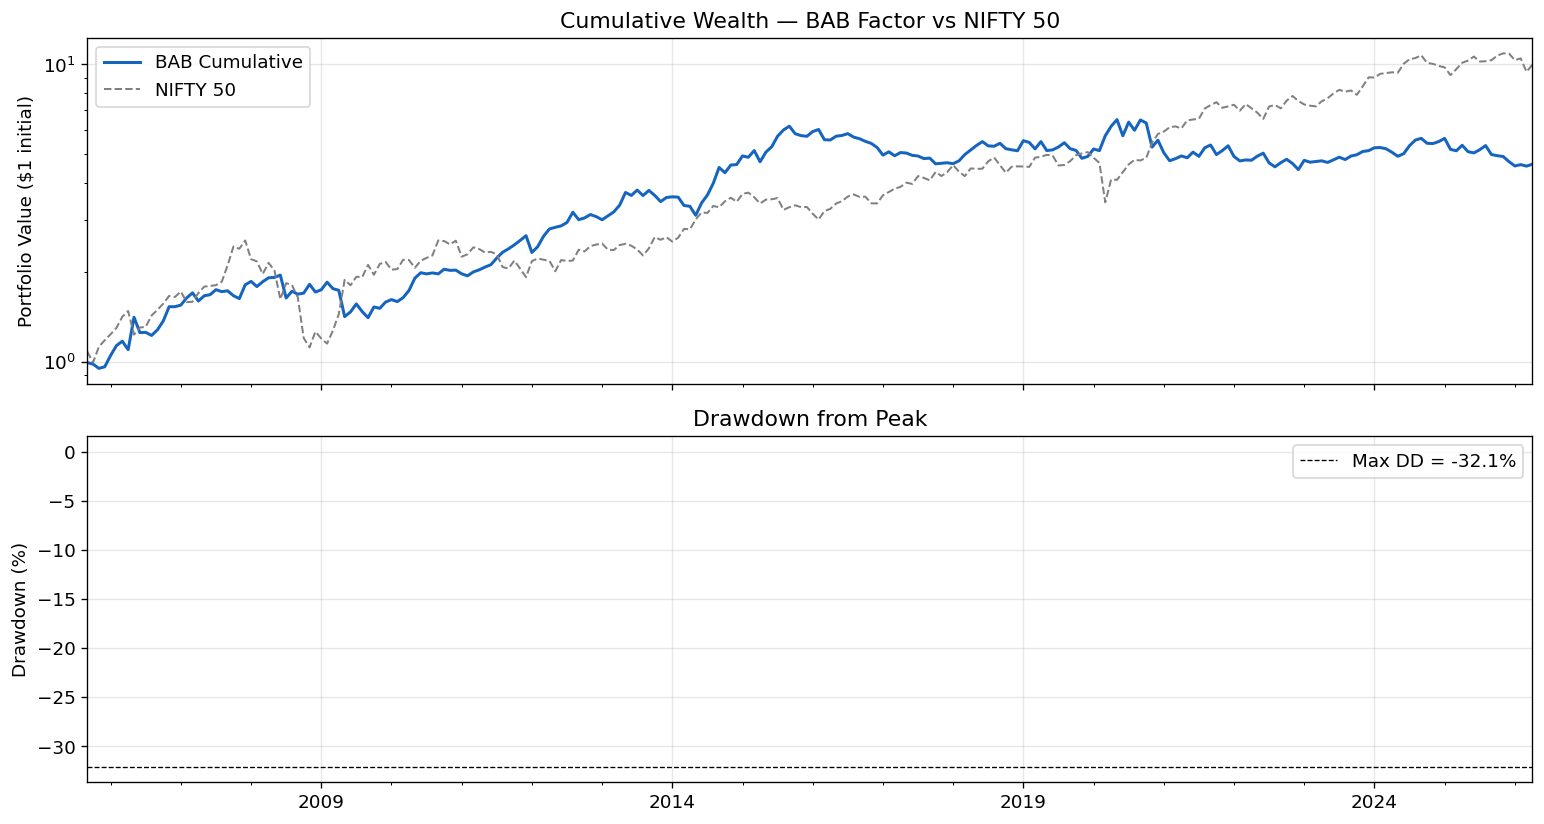

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

cum_bab.plot(ax=axes[0], color='#1565C0', linewidth=1.8, label='BAB Cumulative')
cum_mkt.plot(ax=axes[0], color='gray', linewidth=1.2, linestyle='--', label='NIFTY 50')
axes[0].set_title('Cumulative Wealth — BAB Factor vs NIFTY 50')
axes[0].set_yscale('log')
axes[0].set_ylabel('Portfolio Value ($1 initial)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].fill_between(dd_series.index, dd_series * 100, 0,
                     color='#C62828', alpha=0.6)
axes[1].plot(dd_series.index, dd_series * 100, color='#B71C1C', linewidth=0.8)
axes[1].axhline(mdd_val * 100, color='black', linestyle='--', linewidth=0.8,
                label=f'Max DD = {mdd_val:.1%}')
axes[1].set_title('Drawdown from Peak')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9 · Monthly Return Distribution

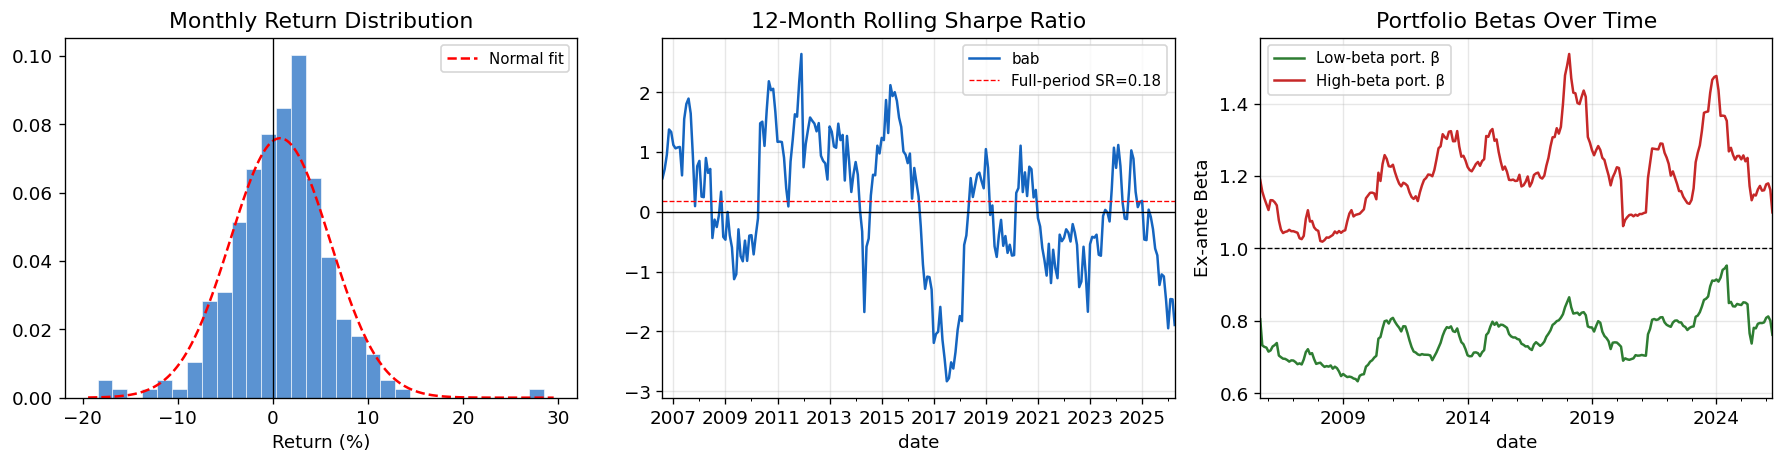

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram with KDE
axes[0].hist(ret_series * 100, bins=30, color='#1565C0', alpha=0.7, density=True,
             edgecolor='white', linewidth=0.5)
x_range = np.linspace(ret_series.min() * 100 - 1, ret_series.max() * 100 + 1, 200)
mu, sig = ret_series.mean() * 100, ret_series.std() * 100
axes[0].plot(x_range, norm.pdf(x_range, mu, sig), 'r--', linewidth=1.5, label='Normal fit')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Monthly Return Distribution')
axes[0].set_xlabel('Return (%)')
axes[0].legend(fontsize=9)

# Rolling 12-month Sharpe
roll_sharpe = ret_series.rolling(12).apply(
    lambda x: sharpe(pd.Series(x), RF_MONTHLY, 12), raw=False
).dropna()
roll_sharpe.plot(ax=axes[1], color='#1565C0')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(sharpe_val, color='red', linestyle='--',
                linewidth=0.8, label=f'Full-period SR={sharpe_val:.2f}')
axes[1].set_title('12-Month Rolling Sharpe Ratio')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Beta of long vs short over time
bab_df['beta_L'].plot(ax=axes[2], color='#2E7D32', label='Low-beta port. β')
bab_df['beta_H'].plot(ax=axes[2], color='#C62828', label='High-beta port. β')
axes[2].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[2].set_title('Portfolio Betas Over Time')
axes[2].set_ylabel('Ex-ante Beta')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10 · Annual Returns Breakdown

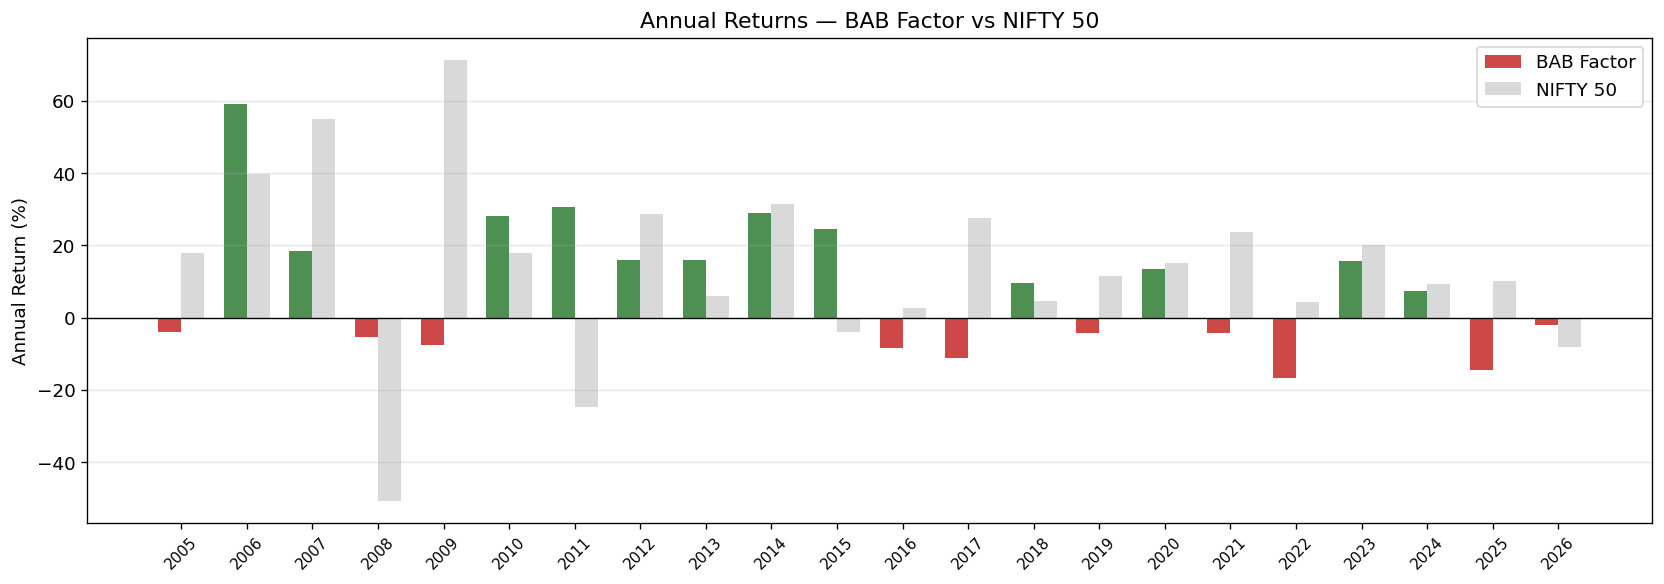

      BAB Factor  NIFTY 50
date                      
2005       -4.0%    +17.9%
2006      +59.2%    +39.8%
2007      +18.5%    +54.9%
2008       -5.4%    -50.6%
2009       -7.5%    +71.5%
2010      +28.0%    +17.9%
2011      +30.6%    -24.6%
2012      +15.9%    +28.7%
2013      +16.0%     +5.9%
2014      +29.0%    +31.5%
2015      +24.5%     -3.9%
2016       -8.3%     +2.8%
2017      -11.1%    +27.5%
2018       +9.7%     +4.5%
2019       -4.3%    +11.7%
2020      +13.5%    +15.1%
2021       -4.3%    +23.8%
2022      -16.8%     +4.3%
2023      +15.8%    +20.1%
2024       +7.3%     +9.2%
2025      -14.4%    +10.1%
2026       -2.0%     -8.2%


In [12]:
annual_bab = bab_ret.resample('YE').apply(lambda x: (1 + x).prod() - 1)
annual_mkt = market_monthly.reindex(bab_ret.index).resample('YE').apply(
    lambda x: (1 + x).prod() - 1
)

annual_df = pd.DataFrame({
    'BAB Factor': annual_bab,
    'NIFTY 50':   annual_mkt
}).dropna(how='all')

annual_df.index = annual_df.index.year

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(annual_df))
w = 0.35
ax.bar(x - w/2, annual_df['BAB Factor'] * 100, w,
       color=['#2E7D32' if v >= 0 else '#C62828' for v in annual_df['BAB Factor']],
       label='BAB Factor', alpha=0.85)
ax.bar(x + w/2, annual_df['NIFTY 50'] * 100, w,
       color='lightgray', label='NIFTY 50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(annual_df.index, rotation=45, fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Annual Returns — BAB Factor vs NIFTY 50')
ax.set_ylabel('Annual Return (%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print table
print(annual_df.mul(100).round(1).to_string(float_format=lambda x: f'{x:+.1f}%'))

## 11 · Summary Statistics Table (replicating paper's Table 3 format)

In [13]:
print('\n' + '='*72)
print('  SUMMARY STATISTICS — BAB FACTOR (Indian Equities)')
print('  Adapted from Table 3 of Frazzini & Pedersen (2014)')
print('='*72)

excess_ret = bab_ret - RF_MONTHLY

summary = {
    'Avg Monthly Excess Return (%)': excess_ret.mean() * 100,
    'Monthly Volatility (%)':        bab_ret.std() * 100,
    'Annualised Volatility (%)':     bab_ret.std() * np.sqrt(12) * 100,
    'Skewness':                      stats.skew(bab_ret),
    'Excess Kurtosis':               stats.kurtosis(bab_ret),
    'Annualised Sharpe Ratio':       sharpe_val,
    'Annualised Sortino Ratio':      sortino_val,
    'Probabilistic Sharpe Ratio':    psr_val,
    'CAGR (%)':                      cagr_val * 100,
    'Max Drawdown (%)':              mdd_val * 100,
    'Win Rate (%)':                  win_rate * 100,
    'Loss Rate (%)':                 loss_rate * 100,
    'Avg Win (monthly %)':           avg_win * 100,
    'Avg Loss (monthly %)':          avg_loss * 100,
    'Profit-Loss Ratio':             pl_ratio,
    'Information Ratio vs NIFTY':    ir_val,
    'Annual Turnover (%)':           annual_turnover * 100,
    'Total Fees on $1 (%)':          total_fees * 100,
}

for k, v in summary.items():
    print(f'  {k:<42s}  {v:>10.4f}')

print('='*72)


  SUMMARY STATISTICS — BAB FACTOR (Indian Equities)
  Adapted from Table 3 of Frazzini & Pedersen (2014)
  Avg Monthly Excess Return (%)                   0.2683
  Monthly Volatility (%)                          5.2533
  Annualised Volatility (%)                      18.1979
  Skewness                                        0.1236
  Excess Kurtosis                                 3.6304
  Annualised Sharpe Ratio                         0.1769
  Annualised Sortino Ratio                        0.1753
  Probabilistic Sharpe Ratio                      0.7892
  CAGR (%)                                        7.6750
  Max Drawdown (%)                              -32.0828
  Win Rate (%)                                   57.6613
  Loss Rate (%)                                  42.3387
  Avg Win (monthly %)                             4.0762
  Avg Loss (monthly %)                           -3.7681
  Profit-Loss Ratio                               1.0818
  Information Ratio vs NIFTY           

## 12 · CAPM Alpha Test

Run a time-series regression of BAB returns on the NIFTY market factor. The intercept (alpha) should be positive and significant if the BAB effect holds in India.

In [14]:
from scipy.stats import t as t_dist

mkt_excess = mkt_aligned - RF_MONTHLY
bab_excess = bab_ret - RF_MONTHLY

# OLS: bab_excess = α + β·mkt_excess + ε
X = np.column_stack([np.ones(len(bab_excess)), mkt_excess.values])
y = bab_excess.values

# OLS solution
beta_ols, resid, _, _ = np.linalg.lstsq(X, y, rcond=None)
alpha_ols, mkt_beta_ols = beta_ols

# Standard errors (heteroskedasticity-robust)
n, k = X.shape
y_hat = X @ beta_ols
e = y - y_hat
sigma2 = (e ** 2).sum() / (n - k)
cov_ols = sigma2 * np.linalg.inv(X.T @ X)
se_alpha = np.sqrt(cov_ols[0, 0])
se_beta  = np.sqrt(cov_ols[1, 1])
t_alpha  = alpha_ols / se_alpha
t_beta   = mkt_beta_ols / se_beta
p_alpha  = 2 * (1 - t_dist.cdf(abs(t_alpha), df=n-k))
r_squared = 1 - (e**2).sum() / ((y - y.mean())**2).sum()

print('CAPM Regression: BAB Excess Return = α + β·Market Excess Return')
print(f'  α (CAPM Alpha): {alpha_ols*100:.4f}%/month   t={t_alpha:.2f}   p={p_alpha:.4f}'
      f'  → Ann. Alpha = {alpha_ols*12*100:.2f}%')
print(f'  β (Market):     {mkt_beta_ols:.4f}             t={t_beta:.2f}')
print(f'  R²:             {r_squared:.4f}')
print()
if p_alpha < 0.05:
    print('  ✓ Alpha is statistically significant at 5% — BAB effect confirmed.')
elif p_alpha < 0.10:
    print('  ~ Alpha is marginally significant at 10%.')
else:
    print('  ✗ Alpha is not statistically significant (may need longer history or more stocks).')

CAPM Regression: BAB Excess Return = α + β·Market Excess Return
  α (CAPM Alpha): 0.4393%/month   t=1.38   p=0.1693  → Ann. Alpha = 5.27%
  β (Market):     -0.2656             t=-5.24
  R²:             0.1004

  ✗ Alpha is not statistically significant (may need longer history or more stocks).


## 13 · Interpretation & Notes

### What this notebook implements

| Paper Element | Implementation |
|---|---|
| Beta estimation | 1yr rolling vol × 5yr rolling corr (Eq. 14) |
| Vasicek shrinkage | 0.6·β_TS + 0.4·1 (Eq. 15) |
| Rank-weighted portfolios | Eq. 16 — scaled so each leg sums to 1 |
| BAB factor construction | Eq. 17 — each leg rescaled to β=1 |
| Monthly rebalancing | End-of-month formation, next-month holding |
| Market benchmark | NIFTY 50 (market-cap weighted index) |

### Key differences from the original paper
- **Universe**: ~49 NIFTY 50 stocks vs 23,000+ US stocks
- **Period**: 2006–2026 (limited by 5yr correlation window start) vs 1926–2012
- **Risk-free rate**: Fixed 6% p.a. proxy vs actual US T-bill data
- **Factor models**: CAPM only (no Fama-French factors for India)
- **No short-selling constraints**: Actual Indian short-selling is restricted — this is a theoretical exercise

### Performance Metric Definitions

| Metric | Formula |
|---|---|
| CAGR | $(1+r_{total})^{1/T} - 1$ |
| Sharpe | $\bar{r}_{excess} / \sigma_r \times \sqrt{12}$ |
| PSR | $\Phi[(\hat{SR} - SR^*) \sqrt{T-1} / \sqrt{1 - \gamma_3 \hat{sr} + (\gamma_4-1)/4 \cdot \hat{sr}^2}]$ |
| Sortino | $\bar{r}_{excess} \times 12 / (\sigma_{downside} \times \sqrt{12})$ |
| Information Ratio | $\bar{r}_{active} / \sigma_{active} \times \sqrt{12}$ |
| Profit-Loss Ratio | $|\text{avg win}| / |\text{avg loss}|$ |